# phl_risk.analysis 全功能实践手册

**定位：可从头运行的中文教程，而非业务结论报告。** 全部数据由固定随机种子生成，无外部文件、账户、网络数据或真实用户信息。案例覆盖当前源码中的公开功能，并把扩展接口放在最后。

阅读路线：先运行 1–2 节建立环境和数据，然后按顺序运行全部单元格。每节包含目的、参数语义、结果展示和必要断言。可预期的异常会被捕获并展示，正常执行不应产生红色错误单元格。

**特别注意**：CountWhere 已删除，使用 Count(where=...)；diagnostics 仍是部分覆盖的框架预览。版本号相同不代表源码相同，环境单元格会列出导入路径和可用参数。

目录：
1. [环境与阅读约定](#s1)
2. [合成数据与字段字典](#s2)
3. [Dimension × Measure 的基本模型](#s3)
4. [Count、Share、Sum、EventRate](#s4)
5. [条件统计：类别、数值、缺失、组合](#s5)
6. [全局 filters 与指标 where](#s6)
7. [Ratio 与条件比例](#s7)
8. [AUC、KS、Context 与权重](#s8)
9. [QuantileBinner 的完整生命周期](#s9)
10. [独立分箱交叉与共享边界](#s10)
11. [CubeResult 与任意轴布局](#s11)
12. [总计与重算口径](#s12)
13. [动态漏斗：明细、汇总与变形](#s13)
14. [缺失策略、无效策略与边界](#s14)
15. [diagnostics 原因追踪](#s15)
16. [PSI：整体、N 维、批量、类别](#s16)
17. [PSI 日期比较、缺失与无效组](#s17)
18. [Plan、Engine、性能与可解释性](#s18)
19. [自定义扩展：Dimension、Measure、比较指标](#s19)
20. [API 索引、配方与验收](#s20)

<a id="s1"></a>

## 1. 环境与阅读约定

推荐 Python 3.12。先在仓库根目录执行 `uv sync --group dev`，再安装教程工具：

```bash
uv pip install nbformat nbclient nbconvert matplotlib
```

在 Notebook 编辑器选择项目 Python 环境，Restart Kernel 后 Run All。本教程从 examples/ 或仓库根目录运行均可；独立分发时需要先安装最新源码包。不会在单元格内自动安装依赖。

表格默认只显示有限行，完整对象留在变量中；图例采用英文以避免系统缺少中文字体。代码中的数值断言检查真实计算，而非仅判断“没有报错”。

In [1]:
import inspect
import logging
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# 本地源码优先；不写入任何系统路径配置。
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "src/phl_risk").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break
import phl_risk  # noqa: E402 — 本地源码路径初始化后导入
import phl_risk.analysis as analysis  # noqa: E402
from phl_risk.analysis import (  # noqa: E402
    AUC,
    KS,
    AnalysisContext,
    AxisSpec,
    BaseDimension,
    BinDimension,
    Col,
    ColumnDimension,
    ComparativeMeasure,
    ComputePolicy,
    Count,
    Cube,
    EventRate,
    Funnel,
    MissingPolicy,
    PandasEngine,
    QuantileBinner,
    Ratio,
    Share,
    SingleSampleMeasure,
    Stage,
    Sum,
    TableLayout,
    Transition,
)
from phl_risk.exceptions import (  # noqa: E402
    InvalidMetricError,
    LayoutError,
    MeasureError,
    NotFittedError,
    TransformError,
)

assert "where" in inspect.signature(Count).parameters, "请安装最新源码，当前环境不支持 Count.where"
assert hasattr(analysis.CubeResult, "diagnostics"), "请安装包含 diagnostics 的源码"
pd.set_option("display.max_rows", 16)
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 5)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
    }
)
display(
    pd.Series(
        {
            "python": sys.version.split()[0],
            "package": phl_risk.__version__,
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "source": phl_risk.__file__,
        },
        name="环境",
    )
)


def expect_error(label, function, expected):
    """仅用于教程展示预期异常；错误类型不符或没有异常时立即失败。"""
    logger = logging.getLogger("phl_risk.analysis")
    previous = logger.disabled
    logger.disabled = True
    try:
        function()
    except expected as error:
        print(f"{label}: {type(error).__name__}: {error}")
    else:
        raise AssertionError(f"{label}: expected {expected.__name__}")
    finally:
        logger.disabled = previous

python                                               3.12.13
package                                                0.5.0
numpy                                                  2.5.2
pandas                                                 3.0.5
source     /Users/xuetao/git_code/phi_risk/src/phl_risk/_...
Name: 环境, dtype: str

<a id="s2"></a>

## 2. 合成数据与字段字典

每行是一条 observation，user_id 在本示例唯一；Count 统计行数，不隐式按 user_id 去重。三个样本集覆盖同样的 6 个日期，便于展示 dt × dataset；PSI 的日期窗口案例后面单独构造。

| 字段 | 含义 |
|---|---|
| dt / dataset / segment / channel | 日期、样本集、分群、渠道维度 |
| score_a / score_b | 同尺度 [0,1] 分数，越大越倾向 label=1 |
| label / weight | 二分类标签、非负样本权重 |
| amount / income / age | 金额、收入、年龄；主数据无缺失 |
| view / click / confirm / withdraw | 嵌套的 0/1 阶段标志 |

主数据保持干净；缺失、类别缺席、无穷、单类等异常只在小案例副本中引入，便于看清原因。

In [2]:
SEED = 20260924
rng = np.random.default_rng(SEED)
n = 3600
latent = rng.normal(size=n)
dataset = np.repeat(["train", "test", "oot"], n // 3)
shift = np.select([dataset == "test", dataset == "oot"], [0.15, 0.65], default=0.0)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


score_a = sigmoid(latent + shift)
score_b = sigmoid(0.8 * latent + shift + rng.normal(0, 0.6, n))
view = np.ones(n, dtype=int)
click = (rng.random(n) < 0.7).astype(int)
confirm = click * (rng.random(n) < 0.6)
withdraw = confirm * (rng.random(n) < 0.5)
df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "dt": np.tile(pd.date_range("2026-09-01", periods=6).strftime("%Y-%m-%d"), n // 6),
        "dataset": dataset,
        "segment": rng.choice(["new", "returning"], n),
        "channel": rng.choice(["web", "app", "partner"], n, p=[0.4, 0.4, 0.2]),
        "score_a": score_a,
        "score_b": score_b,
        "label": rng.binomial(1, sigmoid(latent + shift - 0.4)),
        "weight": rng.uniform(0.5, 2.0, n),
        "amount": rng.integers(1, 100, n).astype(float),
        "income": rng.lognormal(8 + shift / 3, 0.5),
        "age": rng.integers(18, 70, n),
        "view": view,
        "click": click,
        "confirm": confirm,
        "withdraw": withdraw,
    }
)
train = df.loc[df.dataset.eq("train")].copy()
test = df.loc[df.dataset.eq("test")].copy()
oot = df.loc[df.dataset.eq("oot")].copy()
assert not df.isna().any().any()
assert (df.withdraw <= df.confirm).all() and (df.confirm <= df.click).all()
display(df.head(6))
display(
    df.groupby("dataset").agg(
        rows=("user_id", "size"), event_rate=("label", "mean"), mean_score=("score_a", "mean")
    )
)

,user_id,dt,dataset,segment,channel,score_a,...,income,age,view,click,confirm,withdraw
0,0,2026-09-01,train,new,app,0.71055,...,5536.27728,62,1,0,0,0
1,1,2026-09-02,train,new,web,0.58193,...,1200.22523,41,1,1,0,0
2,2,2026-09-03,train,new,app,0.37731,...,6488.93052,30,1,1,1,0
3,3,2026-09-04,train,returning,app,0.58609,...,1987.12117,56,1,1,0,0
4,4,2026-09-05,train,new,web,0.30542,...,6358.22843,19,1,1,1,0
5,5,2026-09-06,train,returning,app,0.50508,...,3220.74052,27,1,1,0,0


,rows,event_rate,mean_score
dataset,,,
oot,1200,0.55833,0.63706
test,1200,0.46583,0.52664
train,1200,0.44000,0.49991


<a id="s3"></a>

## 3. Dimension × Measure：整体、一维与 N 维

`Cube(dimensions, measures)` 描述分析；普通列不需要 fit。dimensions 省略或 [] 表示整体，measures 省略表示 Count()，但显式 [] 是错误。字符串维度等价于 ColumnDimension；name 只改输出维度名。metric 和 value 为保留名称。

In [3]:
overall = Cube().compute(df)
assert overall.layout().iloc[0, 0] == len(df)
display(overall.layout())
one = Cube(["dataset"], [Count(), Share()]).compute(df)
display(one.layout())
assert np.isclose(one.layout()["share"].sum(), 1)
renamed = Cube([ColumnDimension("segment", name="customer_group")], [Count()]).compute(df)
display(renamed.layout())
n_dim = Cube(["dt", "dataset", "segment", "channel"], [Count()]).compute(df)
assert n_dim.ndim == 5  # 四个维度，加一个 metric 轴
assert n_dim.data_.value.sum() == len(df)
display(n_dim.data_.head(8))

metric,count
0,3600.0


metric,count,share
dataset,,
train,1200.0,0.33333
test,1200.0,0.33333
oot,1200.0,0.33333


metric,count
customer_group,
new,1775.0
returning,1825.0


,dt,dataset,segment,channel,metric,value
0,2026-09-01,train,new,app,count,41
1,2026-09-02,train,new,web,count,40
2,2026-09-03,train,new,app,count,46
3,2026-09-04,train,returning,app,count,36
4,2026-09-05,train,new,web,count,44
5,2026-09-06,train,returning,app,count,35
6,2026-09-01,train,returning,web,count,41
7,2026-09-03,train,returning,web,count,43


<a id="s4"></a>

## 4. 基础指标：行数、占比、求和与事件率

Count 包含指标字段缺失的行；Share 是组行数 / 整个分析总体行数，不是每行或每列自动归一化。EventRate 是事件数量 / 非缺失标签数量，event_value 可以指定类别。Sum 默认缺失传播，不是 pandas 默认跳过缺失。

In [4]:
basic = Cube(["dataset"], [Count(), Share(), Sum("amount"), EventRate("label")]).compute(df)
display(basic.layout())
np.testing.assert_allclose(
    basic.layout()["sum__amount"], df.groupby("dataset", sort=False).amount.sum()
)
np.testing.assert_allclose(
    basic.layout()["event_rate__label__1"], df.groupby("dataset", sort=False).label.mean()
)
category_rate = Cube(
    ["dataset"], [EventRate("channel", event_value="app", name="app_rate")]
).compute(df)
display(category_rate.layout())

metric,count,share,sum__amount,event_rate__label__1
dataset,,,,
train,1200.0,0.33333,59538.0,0.44000
test,1200.0,0.33333,58741.0,0.46583
oot,1200.0,0.33333,58590.0,0.55833


metric,app_rate
dataset,
train,0.36083
test,0.41500
oot,0.40250


### 4.1 一个缺失值为什么会让 Sum 返回 NaN
默认 `missing="propagate"` 把未知数量传播到合计；`missing="zero"` 是显式按零处理，全部缺失也会得到零。两者口径不同，不能为了消除空值无条件改为 zero。

In [5]:
tiny = pd.DataFrame(
    {
        "g": ["A", "A", "B", "B"],
        "x": [1.0, np.nan, np.nan, np.nan],
        "label": [1.0, np.nan, np.nan, np.nan],
    }
)
missing_sum = Cube(
    ["g"], [Count(), Sum("x"), Sum("x", missing="zero", name="sum_zero"), EventRate("label")]
).compute(tiny)
display(missing_sum.layout())
assert missing_sum.layout()["sum__x"].isna().all()
assert missing_sum.layout()["sum_zero"].tolist() == [1, 0]

metric,count,sum__x,sum_zero,event_rate__label__1
g,,,,
A,2.0,NaN,1.0,1.0
B,2.0,NaN,0.0,NaN


<a id="s5"></a>

## 5. Count 与 Sum 的统一 where 条件

where 只决定当前指标使用哪些记录，支持类别、数值、缺失和组合。筛选列与求和列可以不同；Sum 的求和列仍必须为实数数值类型。多个同类指标请显式命名，默认名称不会自动追加条件。

| 场景 | 表达式 |
|---|---|
| 等于/不等于 | Col('channel') == 'app' / != 'app' |
| 阈值 | >、>=、<、<= |
| 集合 | Col('channel').isin(['app','web']) |
| 缺失 | isna() / notna() |
| 组合 | (条件1) & (条件2)、(条件1) \| (条件2)、~(条件) |

不要使用 Python and/or/not；不隐式把数字字符串转换成数字。

In [6]:
condition = Col("channel").isin(["app", "web"]) & (Col("age") >= 30)
conditional_cube = Cube(
    ["dataset"],
    [
        Count(name="all_rows"),
        Count(where=condition, name="selected_rows"),
        Sum("amount", where=condition, name="selected_amount"),
        Sum("amount", where=Col("amount") > 10, name="amount_gt10"),
        Count(where=(Col("age") >= 30) & (Col("age") < 40), name="age_30_39"),
    ],
)
conditional = conditional_cube.compute(df, totals=True)
display(conditional.layout(totals=True))
mask = df.channel.isin(["app", "web"]) & df.age.ge(30)
assert conditional.total(over=["dataset"]).layout().loc[0, "selected_rows"] == mask.sum()
assert (
    conditional.total(over=["dataset"]).layout().loc[0, "selected_amount"]
    == df.loc[mask, "amount"].sum()
)

metric,all_rows,selected_rows,selected_amount,amount_gt10,age_30_39
dataset,,,,,
train,1200.0,717.0,36425.0,58871.0,228.0
test,1200.0,738.0,36384.0,58021.0,240.0
oot,1200.0,740.0,36428.0,57894.0,225.0
Total,3600.0,2195.0,109237.0,174786.0,693.0


### 5.1 条件未知、非、零匹配和缺失传播
缺失比较产生未知；取反仍然未知，最终不匹配。OR 中另一条件为真时，整体可为真。没有匹配时 Count/Sum 为 0；选中记录的缺失继续传播，未选中记录的缺失不影响该指标。

In [7]:
cases = pd.DataFrame({"category": ["A", "B", None], "amount": [np.nan, 20.0, 30.0]})
case_result = Cube(
    measures=[
        Count(where=~(Col("category") == "A"), name="not_A"),
        Count(where=Col("category").isna(), name="missing_category"),
        Count(where=(Col("category") == "A") | (Col("amount") > 25), name="A_or_large"),
        Sum("amount", where=Col("category") == "B", name="B_sum"),
        Sum("amount", where=Col("category") == "A", name="A_sum"),
        Sum("amount", where=Col("category") == "Z", name="no_match"),
    ]
).compute(cases)
display(case_result.layout())
assert case_result.layout().loc[0, "not_A"] == 1
assert case_result.layout().loc[0, "missing_category"] == 1
assert case_result.layout().loc[0, "no_match"] == 0
assert pd.isna(case_result.layout().loc[0, "A_sum"])
expect_error(
    "重复默认名称",
    lambda: Cube(measures=[Count(), Count(where=Col("amount") > 10)]).plan(),
    MeasureError,
)

metric,not_A,missing_category,A_or_large,B_sum,A_sum,no_match
0,1.0,1.0,2.0,20.0,NaN,0.0


重复默认名称: MeasureError: Duplicate measure names: ['count', 'count']; supply explicit name=


<a id="s6"></a>

## 6. Cube.filters 与 Measure.where 的边界

filters 依次作用于整个分析总体，并影响 fit 时学到的参考边界；where 不改变分层总体、Share 的分母或分箱边界。filters 支持 Col 表达式或返回对齐布尔 Series 的函数。函数收到隔离副本，但应仍按无副作用方式编写。

In [8]:
global_filtered = Cube(["dataset"], [Count(), Share()], filters=[Col("channel") == "app"]).compute(
    df
)
local_filtered = Cube(
    ["dataset"], [Count(), Count(where=Col("channel") == "app", name="app_count"), Share()]
).compute(df)
display(global_filtered.layout())
display(local_filtered.layout())
assert global_filtered.data_.query("metric == 'count'").value.sum() == df.channel.eq("app").sum()
callback = Cube(measures=[Count()], filters=[lambda frame: frame["age"].between(30, 39)]).compute(
    df
)
assert callback.layout().iloc[0, 0] == df.age.between(30, 39).sum()
display(pd.Series(global_filtered.metadata_)[["input_rows", "filtered_rows", "analyzed_rows"]])

metric,count,share
dataset,,
train,433.0,0.30622
test,498.0,0.35219
oot,483.0,0.34158


metric,count,app_count,share
dataset,,,
train,1200.0,433.0,0.33333
test,1200.0,498.0,0.33333
oot,1200.0,483.0,0.33333


input_rows       3600
filtered_rows    1414
analyzed_rows    1414
dtype: object

<a id="s7"></a>

## 7. Ratio：引用指标名称，而不是原始列

Ratio 用于阶段转化、条件占比、每行平均金额等。分子和分母引用 name，允许声明顺序不同于计算依赖顺序。分母为 0 按 on_invalid 处理；上游 NaN 继续传播。不要把“求和之比”和“逐行比值的平均”混为一谈。

In [9]:
ratio_cube = Cube(
    ["dataset"],
    [
        Ratio("app_count", "all_count", name="app_share"),
        Ratio("amount_total", "all_count", name="mean_amount_per_row"),
        Count(name="all_count"),
        Count(where=Col("channel") == "app", name="app_count"),
        Sum("amount", name="amount_total"),
    ],
)
ratios = ratio_cube.compute(df)
display(ratios.layout())
np.testing.assert_allclose(
    ratios.layout()["mean_amount_per_row"], df.groupby("dataset", sort=False).amount.mean()
)
expect_error(
    "未知依赖",
    lambda: Cube(measures=[Ratio("absent", "rows"), Count(name="rows")]).plan(),
    MeasureError,
)
expect_error(
    "循环依赖",
    lambda: Cube(measures=[Ratio("b", "b", name="a"), Ratio("a", "a", name="b")]).plan(),
    MeasureError,
)

metric,app_share,mean_amount_per_row,all_count,app_count,amount_total
dataset,,,,,
train,0.36083,49.61500,1200.0,433.0,59538.0
test,0.41500,48.95083,1200.0,498.0,58741.0
oot,0.40250,48.82500,1200.0,483.0,58590.0


未知依赖: MeasureError: Unknown measure reference 'absent'
循环依赖: MeasureError: Cyclic measure reference involving 'a'


<a id="s8"></a>

## 8. AUC / KS：分层、默认上下文与权重

AUC/KS 的 score 越大必须越倾向 target=1；标签要求 0/1。始终使用关键字 score=、target=，避免位置参数颠倒。每个指标独立删除缺失标签、非有限分数和零权重，再检查两类有效样本。

AnalysisContext 提供默认 target/weight，Measure 的显式配置优先。权重影响 AUC、KS、EventRate；不把 Count/Sum/Share 变为加权指标。

In [10]:
performance_cube = Cube(
    ["dt", "dataset"],
    [Count(), AUC(score="score_a"), KS(score="score_a"), AUC(score="score_b", name="auc_b")],
)
performance = performance_cube.compute(df, context=AnalysisContext(target="label"), totals=True)
display(performance.layout().head(9))
weighted = Cube(
    ["dataset"],
    [
        Count(),
        AUC(score="score_a"),
        KS(score="score_a"),
        EventRate(),
        EventRate(weight="weight", target="label", name="explicit_rate"),
    ],
).compute(df, context=AnalysisContext(target="label", weight="weight"))
display(weighted.layout())
for group, data in df.groupby("dataset"):
    assert np.isclose(
        weighted.layout().loc[group, "explicit_rate"], np.average(data.label, weights=data.weight)
    )

metric              count  auc__score_a  ks__score_a    auc_b
dt         dataset                                           
2026-09-01 train    200.0       0.74947      0.42262  0.69735
           test     200.0       0.72346      0.37282  0.69170
           oot      200.0       0.80152      0.47259  0.68617
2026-09-02 train    200.0       0.77519      0.43404  0.75981
           test     200.0       0.70637      0.35124  0.65517
           oot      200.0       0.68368      0.29509  0.65097
2026-09-03 train    200.0       0.78466      0.42707  0.69744
           test     200.0       0.70992      0.31250  0.68598
           oot      200.0       0.71040      0.37333  0.69109

metric,count,auc__score_a,ks__score_a,event_rate__label__1,explicit_rate
dataset,,,,,
train,1200.0,0.76356,0.41524,0.44113,0.44113
test,1200.0,0.73011,0.34887,0.46595,0.46595
oot,1200.0,0.75106,0.38551,0.55500,0.55500


### 8.1 独立数学对照与分层趋势
这里只把 sklearn 作为对照，不另写 AUC 算法。日期样本量有限，曲线波动不是模型衰减的业务证据；数据是人工生成的。

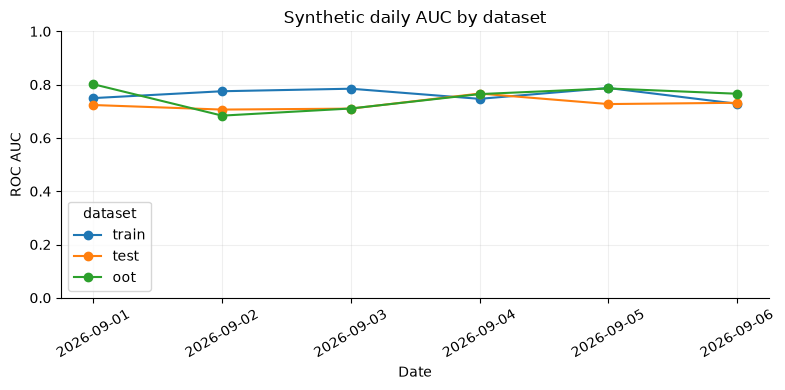

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

actual = performance.total(over=["dt"]).layout().loc["train", "auc__score_a"]
assert np.isclose(actual, roc_auc_score(train.label, train.score_a))
fpr, tpr, _ = roc_curve(train.label, train.score_a)
assert np.isclose(
    performance.total(over=["dt"]).layout().loc["train", "ks__score_a"], (tpr - fpr).max()
)
trend = performance.layout()["auc__score_a"].unstack("dataset")
ax = trend.plot(marker="o", ylim=(0, 1), title="Synthetic daily AUC by dataset")
ax.set(xlabel="Date", ylabel="ROC AUC")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<a id="s9"></a>

## 9. QuantileBinner：学习、应用、边界与显示

n_bins 是目标箱数，边界来自参考有限值的 np.quantile；重复边界默认合并，实际箱数可能减少。两端扩展到 -inf/+inf，默认右闭；相同分数不拆箱。新样本不保证等频。

precision 默认六位小数，仅控制区间标签；相邻显示边界冲突会自动增加位数。bin_edges_ 保留原始浮点精度。include_lowest 控制 -inf 是否归入首箱，不是改变所有有限区间闭合规则。

,label,interval
0,B1,"[-inf, 0.30]"
1,B2,"(0.30, 0.44]"
2,B3,"(0.44, 0.56]"
3,B4,"(0.56, 0.70]"
4,B5,"(0.70, inf]"


0       -inf
1    0.30139
2    0.43569
3    0.55869
4    0.70482
5        inf
Name: 精确边界, dtype: float64

,train,oot
score_a,,
B1,240,81
B2,240,131
B3,240,183
B4,240,297
B5,240,508


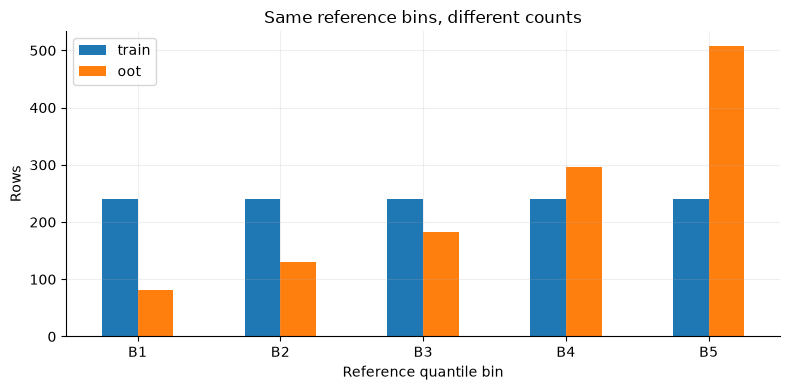

In [12]:
binner = QuantileBinner(n_bins=5, precision=2)
assert not binner.is_fitted
binner.fit(train.score_a)
assert binner.is_fitted
display(pd.DataFrame({"label": binner.labels_, "interval": binner.metadata()["intervals"]}))
display(pd.Series(binner.bin_edges_, name="精确边界"))
reference_bins = binner.transform(train.score_a)
current_bins = binner.transform(oot.score_a)
frequency = pd.DataFrame(
    {"train": reference_bins.value_counts(sort=False), "oot": current_bins.value_counts(sort=False)}
)
display(frequency)
frequency.plot.bar(title="Same reference bins, different counts", rot=0)
plt.ylabel("Rows")
plt.xlabel("Reference quantile bin")
plt.tight_layout()
plt.show()

### 9.1 直接使用 transformer 与异常边界
fit_transform(X) 等于 fit(X) 再 transform(X)；Cube 中的 fit_compute 是相似但不同的入口。自定义 labels 数量必须等于实际箱数。

In [13]:
probe = pd.Series(
    [-np.inf, binner.bin_edges_[1], np.inf, np.nan], index=["low", "edge", "high", "missing"]
)
display(binner.transform(probe))
assert binner.transform(probe).iloc[1] == "B1"
assert pd.isna(binner.transform(probe).iloc[-1])
custom = QuantileBinner(2, labels=["low", "high"]).fit_transform(pd.Series([1, 2, 3, 4]))
display(custom)
constant = QuantileBinner(5).fit([1, 1, 1])
assert constant.n_bins_ == 1
assert pd.isna(QuantileBinner(1, include_lowest=False).fit([1]).transform([-np.inf]).iloc[0])
expect_error(
    "重复分位点严格模式",
    lambda: QuantileBinner(5, duplicates="raise").fit([1, 1, 1]),
    TransformError,
)
expect_error("尚未拟合", lambda: QuantileBinner(5).transform([1]), NotFittedError)
expect_error("参考无有限值", lambda: QuantileBinner().fit([np.nan, np.inf]), TransformError)
close = QuantileBinner(4, precision=2).fit([0.12345671, 0.12345672, 0.12345673, 0.12345674])
display(close.metadata()["intervals"])

low         B1
edge        B1
high        B5
missing    NaN
dtype: category
Categories (5, str): ['B1' < 'B2' < 'B3' < 'B4' < 'B5']

0     low
1     low
2    high
3    high
dtype: category
Categories (2, str): ['low' < 'high']

重复分位点严格模式: TransformError: Duplicate reference quantile edges; use duplicates='drop'
尚未拟合: NotFittedError: QuantileBinner requires fit(reference) before transform(current)
参考无有限值: TransformError: QuantileBinner reference has no finite observations


('[-inf, 0.123456718]',
 '(0.123456718, 0.123456725]',
 '(0.123456725, 0.123456732]',
 '(0.123456732, inf]')

<a id="s10"></a>

## 10. 双分数交叉：独立等频边界与同一分数段

两种问题不同：独立分箱比较各自分位排名；共享边界比较相同数值区间。fit_compute(oot) 完全适合只分析 OOT 自身；fit(train).compute(oot) 适合固定参考。分箱是学习阈值，不是训练预测模型。

In [14]:
cross_cube = Cube(
    [BinDimension("score_a", QuantileBinner(5)), BinDimension("score_b", QuantileBinner(5))],
    [Count(), Share(), EventRate("label", name="event_rate")],
)
cross = cross_cube.fit_compute(oot, totals=True)
assert cross_cube.is_fitted
vertical = cross.layout(
    rows=["metric", "score_a_bin"], columns=["score_b_bin"], totals=True, total_label="总计"
)
display(vertical)
assert cross.total(over=["score_a_bin", "score_b_bin"]).layout().loc[0, "count"] == len(oot)

score_b_bin                    B1        B2        B3        B4         B5  \
metric     score_a_bin                                                       
count      B1           157.00000  53.00000  22.00000   8.00000    0.00000   
           B2            69.00000  85.00000  56.00000  25.00000    5.00000   
           B3            12.00000  73.00000  75.00000  58.00000   22.00000   
           B4             2.00000  26.00000  65.00000  87.00000   60.00000   
           B5             0.00000   3.00000  22.00000  62.00000  153.00000   
...                           ...       ...       ...       ...        ...   
event_rate B2             0.44928   0.43529   0.50000   0.40000    0.60000   
           B3             0.58333   0.45205   0.56000   0.58621    0.54545   
           B4             0.00000   0.76923   0.70769   0.78161    0.66667   
           B5                 NaN   0.66667   0.86364   0.85484    0.84314   
           总计             0.29583   0.45833   0.57083   0.70000    0.76667   

score_b_bin                    总计  
metric     score_a_bin             
count      B1           240.00000  
           B2           240.00000  
           B3           240.00000  
           B4           240.00000  
           B5           240.00000  
...                           ...  
event_rate B2             0.45417  
           B3             0.53333  
           B4             0.72500  
           B5             0.84583  
           总计             0.55833  

[18 rows x 6 columns]

### 10.1 fit_field：从 score_a 学习，再分别转换两列
fit_field 指向输入原始列，不是另一个 Dimension；不依赖维度顺序。相同参考数据、学习列和分箱配置才保证同边界。score_b 不保证等频，两个分数应使用可比较的尺度。

In [15]:
shared_cube = Cube(
    [
        BinDimension("score_a", QuantileBinner(5)),
        BinDimension("score_b", QuantileBinner(5), fit_field="score_a"),
    ],
    [Count(), Share()],
).fit(train)
learned_a, learned_b = shared_cube.dimensions_
np.testing.assert_array_equal(learned_a.transformer.bin_edges_, learned_b.transformer.bin_edges_)
shared = shared_cube.compute(oot, totals=True)
display(
    shared.layout(rows=["score_a_bin"], columns=["metric", "score_b_bin"], bin_labels="interval")
)
print("学习来源:", learned_b.metadata()["fit_field"])
# 单个 score_b 维度：fit 时不需要 score_b，compute 时不需要 score_a。
transfer = Cube([BinDimension("score_b", QuantileBinner(3), fit_field="score_a")], [Count()])
transfer.fit(train[["score_a"]])
display(transfer.compute(oot[["score_b"]]).layout())

metric                          count                       \
score_b_bin          [-inf, 0.301390] (0.301390, 0.435687]   
score_a_bin                                                  
[-inf, 0.301390]                 43.0                 26.0   
(0.301390, 0.435687]             23.0                 37.0   
(0.435687, 0.558686]             10.0                 42.0   
(0.558686, 0.704816]              6.0                 18.0   
(0.704816, inf]                   0.0                  4.0   

metric                                                          \
score_b_bin          (0.435687, 0.558686] (0.558686, 0.704816]   
score_a_bin                                                      
[-inf, 0.301390]                     10.0                  2.0   
(0.301390, 0.435687]                 37.0                 26.0   
(0.435687, 0.558686]                 52.0                 56.0   
(0.558686, 0.704816]                 60.0                123.0   
(0.704816, inf]                      25.0                 88.0   

metric                                          share                       \
score_b_bin          (0.704816, inf] [-inf, 0.301390] (0.301390, 0.435687]   
score_a_bin                                                                  
[-inf, 0.301390]                 0.0          0.03583              0.02167   
(0.301390, 0.435687]             8.0          0.01917              0.03083   
(0.435687, 0.558686]            23.0          0.00833              0.03500   
(0.558686, 0.704816]            90.0          0.00500              0.01500   
(0.704816, inf]                391.0          0.00000              0.00333   

metric                                                                          
score_b_bin          (0.435687, 0.558686] (0.558686, 0.704816] (0.704816, inf]  
score_a_bin                                                                     
[-inf, 0.301390]                  0.00833              0.00167         0.00000  
(0.301390, 0.435687]              0.03083              0.02167         0.00667  
(0.435687, 0.558686]              0.04333              0.04667         0.01917  
(0.558686, 0.704816]              0.05000              0.10250         0.07500  
(0.704816, inf]                   0.02083              0.07333         0.32583

学习来源: score_a


metric,count
score_b_bin,
B1,153.0
B2,323.0
B3,724.0


### 10.2 用热力图读取交叉格
下面每格是观察条数，没有除以行合计或列合计。Share 的分母是全部分析行，如需行归一化应显式用 pandas 对 Count 表操作，并说明新的分母。

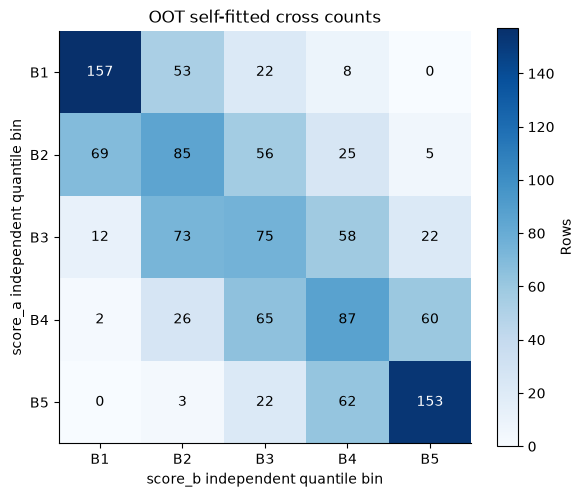

score_b_bin,B1,B2,B3,B4,B5
score_a_bin,,,,,
B1,0.65417,0.22083,0.09167,0.03333,0.00000
B2,0.28750,0.35417,0.23333,0.10417,0.02083
B3,0.05000,0.30417,0.31250,0.24167,0.09167
B4,0.00833,0.10833,0.27083,0.36250,0.25000
B5,0.00000,0.01250,0.09167,0.25833,0.63750


In [16]:
cross_counts = cross.layout(rows=["score_a_bin"], columns=["metric", "score_b_bin"])["count"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cross_counts.to_numpy(), cmap="Blues", vmin=0)
ax.set_xticks(range(5), cross_counts.columns)
ax.set_yticks(range(5), cross_counts.index)
for i in range(5):
    for j in range(5):
        ax.text(
            j,
            i,
            int(cross_counts.iloc[i, j]),
            ha="center",
            va="center",
            color="white"
            if cross_counts.iloc[i, j] > cross_counts.to_numpy().max() * 0.65
            else "black",
        )
ax.set(
    xlabel="score_b independent quantile bin",
    ylabel="score_a independent quantile bin",
    title="OOT self-fitted cross counts",
)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Rows")
plt.tight_layout()
plt.show()
row_share = cross_counts.div(cross_counts.sum(axis=1).replace(0, np.nan), axis=0)
display(row_share)
np.testing.assert_allclose(row_share.sum(axis=1), 1)

<a id="s11"></a>

## 11. CubeResult：长表、轴、布局和安全副本

data_ 是只包含实际观测分组的 canonical 长表；axes 保存完整逻辑域。layout 将每个轴恰好放一次，rows/columns 可以重排 metric；不重新计算、不聚合重复格。max_cells 限制展示大小。普通非类别维度默认按观察顺序，排序可在返回的 pandas 表上显式完成。

In [17]:
display(performance.data_.head(8))
display(
    pd.DataFrame(
        [{"name": a.name, "role": a.role, "size": len(a.values)} for a in performance.axes]
    )
)
print("shape=", performance.shape, "ndim=", performance.ndim)
print("metrics=", [m.name for m in performance.measures_])
print("dimensions=", [a.name for a in performance.dimensions_])
display(performance.layout(rows=["dt"], columns=["metric", "dataset"]).head(4))
manual_unstack = performance.layout().unstack(level="dataset")
pd.testing.assert_frame_equal(
    manual_unstack, performance.layout(rows=["dt"], columns=["metric", "dataset"])
)
layout_object = TableLayout(rows=("dataset",), columns=("metric", "dt"))
display(layout_object.render(performance).iloc[:, :6])
copy_of_data = performance.data_
copy_of_data["value"] = -999
assert not performance.data_.value.eq(-999).any()
expect_error("遗漏逻辑轴", lambda: performance.layout(rows=["dt"], columns=["metric"]), LayoutError)
expect_error("展示规模限制", lambda: performance.layout(max_cells=1), LayoutError)

,dt,dataset,metric,value
0,2026-09-01,train,count,200.0
1,2026-09-02,train,count,200.0
2,2026-09-03,train,count,200.0
3,2026-09-04,train,count,200.0
4,2026-09-05,train,count,200.0
5,2026-09-06,train,count,200.0
6,2026-09-01,test,count,200.0
7,2026-09-02,test,count,200.0


,name,role,size
0,dt,dimension,6
1,dataset,dimension,3
2,metric,metric,4


shape= (6, 3, 4) ndim= 3
metrics= ['count', 'auc__score_a', 'ks__score_a', 'auc_b']
dimensions= ['dt', 'dataset']


metric      count               auc__score_a                   ks__score_a  \
dataset     train   test    oot        train     test      oot       train   
dt                                                                           
2026-09-01  200.0  200.0  200.0      0.74947  0.72346  0.80152     0.42262   
2026-09-02  200.0  200.0  200.0      0.77519  0.70637  0.68368     0.43404   
2026-09-03  200.0  200.0  200.0      0.78466  0.70992  0.71040     0.42707   
2026-09-04  200.0  200.0  200.0      0.74667  0.76649  0.76445     0.42498   

metric                          auc_b                    
dataset        test      oot    train     test      oot  
dt                                                       
2026-09-01  0.37282  0.47259  0.69735  0.69170  0.68617  
2026-09-02  0.35124  0.29509  0.75981  0.65517  0.65097  
2026-09-03  0.31250  0.37333  0.69744  0.68598  0.69109  
2026-09-04  0.46071  0.43456  0.66260  0.74457  0.67794

metric       count                                                       
dt      2026-09-01 2026-09-02 2026-09-03 2026-09-04 2026-09-05 2026-09-06
dataset                                                                  
train        200.0      200.0      200.0      200.0      200.0      200.0
test         200.0      200.0      200.0      200.0      200.0      200.0
oot          200.0      200.0      200.0      200.0      200.0      200.0

遗漏逻辑轴: LayoutError: Place each axis exactly once: ('dt', 'dataset', 'metric'); got ('dt', 'metric')
展示规模限制: LayoutError: Layout needs 72 cells, exceeding max_cells=1


### 11.1 不存在的组合与 categorical 完整域
layout 中的 NaN 不一定来自计算。下面只观测 d1/train 和 d2/oot，但 layout 补出另两格；Count 为 0，AUC 为 NaN。声明类别还能保留未出现的分类。

In [18]:
sparse = pd.DataFrame(
    {
        "dt": ["d1", "d1", "d2", "d2"],
        "dataset": ["train", "train", "oot", "oot"],
        "y": [0, 1, 0, 1],
        "s": [0.1, 0.9, 0.2, 0.8],
    }
)
sparse_result = Cube(["dt", "dataset"], [Count(), AUC(score="s", target="y")]).compute(sparse)
assert not sparse_result.data_.value.isna().any()
assert sparse_result.layout().isna().any().any()
assert sparse_result.diagnostics().empty
display(sparse_result.layout())
categorical_frame = pd.DataFrame(
    {"g": pd.Categorical(["A"], categories=["B", "A", "C"], ordered=True)}
)
display(Cube(["g"], [Count(), Share()]).compute(categorical_frame).layout())

metric      count  auc__s
dt dataset               
d1 train      2.0     1.0
   oot        0.0     NaN
d2 train      0.0     NaN
   oot        2.0     1.0

metric,count,share
g,,
B,0.0,0.0
A,1.0,1.0
C,0.0,0.0


<a id="s12"></a>

## 12. 总计：合并原始样本重新计算

必须在 compute/fit_compute 中传 totals=True 才能展示总计。total(over=[...]) 表示折叠这些维度，不是保留这些维度。layout(totals=['某维度']) 只展示指定维度总计，后台仍已计算所有允许的粒度。

AUC/KS/比率的总计不是分组指标的均值；分箱不重新 fit，过滤和维度缺失处理后的样本总体保持一致。最多允许 64 个 grouping sets，即完整 totals 至多 6 个维度。比较分析暂不支持 totals。

In [19]:
display(
    performance.layout(
        rows=["dt"], columns=["metric", "dataset"], totals=["dt"], total_label="总计"
    ).tail(3)
)
display(performance.total(over=["dt"]).layout())
display(performance.total(over=["dt", "dataset"]).layout())
pooled_example = pd.DataFrame({"g": ["A", "B"], "visits": [100, 10], "done": [10, 9]})
pooled = Cube(
    ["g"],
    [Sum("visits", name="visits"), Sum("done", name="done"), Ratio("done", "visits", name="rate")],
).compute(pooled_example, totals=True)
assert np.isclose(pooled.total(over=["g"]).layout().loc[0, "rate"], 19 / 110)
assert not np.isclose(pooled.layout().rate.mean(), 19 / 110)
display(pooled.layout(totals=True))
expect_error(
    "未预计算总计", lambda: Cube(["dataset"]).compute(df).total(over=["dataset"]), LayoutError
)

metric       count                 auc__score_a                   ks__score_a  \
dataset      train    test     oot        train     test      oot       train   
dt                                                                              
2026-09-05   200.0   200.0   200.0      0.78732  0.72705  0.78563     0.48470   
2026-09-06   200.0   200.0   200.0      0.72818  0.73189  0.76581     0.37494   
总计          1200.0  1200.0  1200.0      0.76107  0.72715  0.75269     0.40909   

metric                          auc_b                    
dataset        test      oot    train     test      oot  
dt                                                       
2026-09-05  0.35271  0.50401  0.73483  0.67993  0.77358  
2026-09-06  0.36955  0.45074  0.73043  0.65856  0.73033  
总计          0.34285  0.39755  0.71004  0.68621  0.70010

metric,count,auc__score_a,ks__score_a,auc_b
dataset,,,,
train,1200.0,0.76107,0.40909,0.71004
test,1200.0,0.72715,0.34285,0.68621
oot,1200.0,0.75269,0.39755,0.70010


metric,count,auc__score_a,ks__score_a,auc_b
0,3600.0,0.75173,0.37782,0.70464


metric,visits,done,rate
g,,,
A,100.0,10.0,0.10000
B,10.0,9.0,0.90000
Total,110.0,19.0,0.17273


未预计算总计: LayoutError: Totals were not computed; use cube.compute(data, totals=True)


<a id="s13"></a>

## 13. Funnel：动态阶段数量与转化

Funnel 只展开 Measure，不处理数据。字符串阶段生成 Sum；Stage 可使用 Count(where=...) 或 Sum。阶段名决定“阶段名数量”的指标名。框架不验证逐行阶段嵌套或自动去重，输入的包含关系由使用者保证。

rates='adjacent' 相邻转换；'from_first' 从首阶段转换；'both' 合并去重；显式 Transition 可选择任意向前的阶段。

In [20]:
funnel = Funnel(["view", "click", "confirm", "withdraw"], rates="both")
display(
    pd.DataFrame(
        {
            "measure": [m.name for m in funnel.measures()],
            "type": [type(m).__name__ for m in funnel.measures()],
        }
    )
)
funnel_result = Cube(["dataset"], funnel.measures()).compute(df, totals=True)
display(funnel_result.layout(totals=True))
assert np.isclose(
    funnel_result.total(over=["dataset"]).layout().loc[0, "view→withdraw转化率"],
    df.withdraw.sum() / df.view.sum(),
)
custom_funnel = Funnel(
    ["view", "click", "confirm", "withdraw"],
    rates=[Transition("view", "withdraw", name="end_to_end")],
)
display(Cube(["segment"], custom_funnel.measures()).compute(df).layout())

,measure,type
0,view数量,Sum
1,click数量,Sum
2,confirm数量,Sum
3,withdraw数量,Sum
4,view→click转化率,Ratio
5,click→confirm转化率,Ratio
6,confirm→withdraw转化率,Ratio
7,view→confirm转化率,Ratio
8,view→withdraw转化率,Ratio


metric,view数量,click数量,confirm数量,withdraw数量,view→click转化率,click→confirm转化率,confirm→withdraw转化率,view→confirm转化率,view→withdraw转化率
dataset,,,,,,,,,
train,1200.0,857.0,502.0,258.0,0.71417,0.58576,0.51394,0.41833,0.21500
test,1200.0,838.0,515.0,268.0,0.69833,0.61456,0.52039,0.42917,0.22333
oot,1200.0,821.0,481.0,228.0,0.68417,0.58587,0.47401,0.40083,0.19000
Total,3600.0,2516.0,1498.0,754.0,0.69889,0.59539,0.50334,0.41611,0.20944


metric,view数量,click数量,confirm数量,withdraw数量,end_to_end
segment,,,,,
new,1775.0,1228.0,721.0,366.0,0.2062
returning,1825.0,1288.0,777.0,388.0,0.2126


### 13.1 已汇总数量、事件明细与分箱漏斗
汇总数据不应 Count 行来代表阶段人数，应 Sum 数量。事件状态可以通过条件计数变成嵌套阶段。任何普通维度或 BinDimension 都可以复用。

In [21]:
aggregated = df.groupby(["dataset", "dt"], as_index=False, sort=False)[
    ["view", "click", "confirm", "withdraw"]
].sum()
from_aggregates = Cube(["dataset"], funnel.measures()).compute(aggregated)
pd.testing.assert_frame_equal(from_aggregates.layout(), funnel_result.layout())
statuses = pd.DataFrame({"status": ["view", "click", "done", "done", None]})
status_funnel = Funnel(
    [
        Stage("view", Count(where=Col("status").isin(["view", "click", "done"]))),
        Stage("click", Count(where=Col("status").isin(["click", "done"]))),
        Stage("done", Count(where=Col("status") == "done")),
    ]
)
display(Cube(measures=status_funnel.measures()).compute(statuses).layout())
binned_funnel = (
    Cube([BinDimension("score_a", QuantileBinner(4))], funnel.measures())
    .fit(train)
    .compute(oot, totals=True)
)
display(binned_funnel.layout(bin_labels="interval", totals=True))

metric,view数量,click数量,done数量,view→click转化率,click→done转化率
0,4.0,3.0,2.0,0.75,0.66667


metric,view数量,click数量,confirm数量,withdraw数量,view→click转化率,click→confirm转化率,confirm→withdraw转化率,view→confirm转化率,view→withdraw转化率
score_a_bin,,,,,,,,,
"[-inf, 0.338979]",111.0,71.0,40.0,18.0,0.63964,0.56338,0.45000,0.36036,0.16216
"(0.338979, 0.495110]",183.0,124.0,80.0,49.0,0.67760,0.64516,0.61250,0.43716,0.26776
"(0.495110, 0.662888]",296.0,215.0,122.0,51.0,0.72635,0.56744,0.41803,0.41216,0.17230
"(0.662888, inf]",610.0,411.0,239.0,110.0,0.67377,0.58151,0.46025,0.39180,0.18033
Total,1200.0,821.0,481.0,228.0,0.68417,0.58587,0.47401,0.40083,0.19000


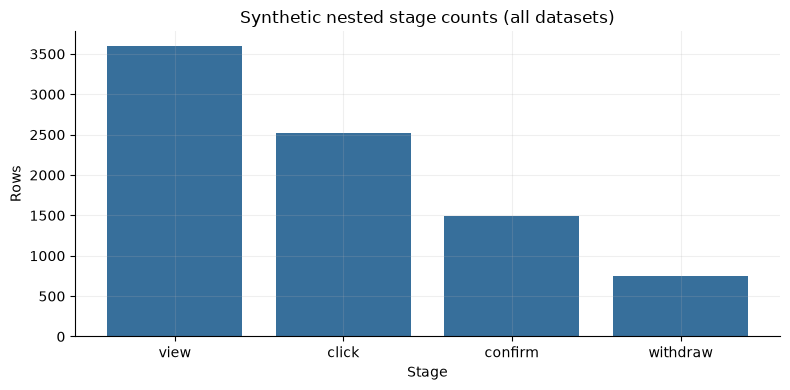

In [22]:
stage_totals = funnel_result.total(over=["dataset"]).layout().iloc[0]
names = ["view", "click", "confirm", "withdraw"]
fig, ax = plt.subplots()
ax.bar(names, [stage_totals[f"{s}数量"] for s in names], color="#376f9b")
ax.set(title="Synthetic nested stage counts (all datasets)", xlabel="Stage", ylabel="Rows")
plt.tight_layout()
plt.show()

<a id="s14"></a>

## 14. MissingPolicy、ComputePolicy 与无效组

维度缺失默认 drop：只要任一分析维度缺失，该行就离开所有指标的分析总体。keep 把缺失保留为独立组。target/score 当前只支持指标内 drop。

on_invalid='nan' 默认返回空；'warn' 发出警告并返回空；'raise' 抛出异常。配置、类型或缺列错误通常直接报错，并非所有错误都转为 NaN。Sum 的 propagate 属于正常缺失语义，不会因为 on_invalid='raise' 自动报错。

In [23]:
dim_missing = pd.DataFrame({"g": ["A", None, "A"], "x": [1.0, 2.0, 3.0]})
dropped = Cube(["g"], [Count(), Sum("x")]).compute(dim_missing)
kept = Cube(
    ["g"], [Count(), Sum("x")], policy=ComputePolicy(missing=MissingPolicy(dimension="keep"))
).compute(dim_missing)
display(dropped.layout())
display(kept.layout())
assert dropped.data_.query("metric == 'count'").value.sum() == 2
assert kept.data_.query("metric == 'count'").value.sum() == 3
single_class = pd.DataFrame({"y": [1, 1], "s": [0.2, 0.9]})
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    invalid_result = Cube(
        measures=[AUC(score="s", target="y")], policy=ComputePolicy(on_invalid="warn")
    ).compute(single_class)
print("捕获的预期警告:", [str(w.message) for w in caught])
expect_error(
    "单一类别严格模式",
    lambda: Cube(
        measures=[AUC(score="s", target="y")], policy=ComputePolicy(on_invalid="raise")
    ).compute(single_class),
    InvalidMetricError,
)
empty_global = Cube(measures=[Count(), Share(), Sum("x")]).compute(
    pd.DataFrame({"x": pd.Series(dtype=float)})
)
display(empty_global.layout())

metric,count,sum__x
g,,
A,2.0,4.0


metric,count,sum__x
g,,
A,2.0,4.0
NaN,1.0,2.0


捕获的预期警告: ['AUC/KS require positive effective weight in both classes']
单一类别严格模式: InvalidMetricError: auc, group=0: AUC/KS require positive effective weight in both classes


metric,count,share,sum__x
0,0.0,NaN,0.0


<a id="s15"></a>

## 15. diagnostics：不修改 NaN，只解释原因

当前是框架预览，不是全部指标诊断。索引为维度 + metric，无维度时只有 metric；多个原因可以共享索引。

| reason | 已实现含义 |
|---|---|
| missing_propagated | Sum 选中行缺失，传播为 NaN |
| upstream_missing | Ratio/漏斗依赖指标为空 |
| zero_denominator | Ratio/漏斗分母为零 |
| reason_not_recorded | 计算为空但未记录详细原因，不能据此推断真实数据问题 |

input_rows 是整组分析行数，affected_rows 当前指 Sum 匹配行中的缺失数；dependency 是指标名。AUC/KS、EventRate、PSI、溢出的详细原因未接入。layout 补齐空组合不在报告中。总计要单独查询。

In [24]:
diagnostic_data = pd.DataFrame(
    {"segment": ["A"] * 1000, "before": [1.0] * 1000, "after": [1.0] * 999 + [np.nan]}
)
diag_result = Cube(["segment"], Funnel(["before", "after"]).measures()).compute(
    diagnostic_data, totals=True
)
display(diag_result.layout())
report = diag_result.diagnostics()
display(report)
assert report.loc[("A", "after数量"), "affected_rows"] == 1
display(report.loc[report.reason.eq("missing_propagated")])
display(diag_result.total(over=["segment"]).diagnostics())
display(invalid_result.diagnostics())
assert invalid_result.diagnostics().reason.eq("reason_not_recorded").all()
zero_result = Cube(measures=Funnel(["before", "after"]).measures()).compute(
    pd.DataFrame({"before": [0.0], "after": [0.0]})
)
display(zero_result.diagnostics())

metric,before数量,after数量,before→after转化率
segment,,,
A,1000.0,NaN,NaN


reason  field  input_rows  affected_rows  \
segment metric                                                                  
A       after数量          missing_propagated  after        1000              1   
        before→after转化率    upstream_missing    NaN        1000           <NA>   

                        dependency  \
segment metric                       
A       after数量                NaN   
        before→after转化率    after数量   

                                                               message  
segment metric                                                          
A       after数量          after: 1 missing values; missing='propagate'.  
        before→after转化率               Dependency 'after数量' is missing.

,,reason,field,input_rows,affected_rows,dependency,message
segment,metric,,,,,,
A,after数量,missing_propagated,after,1000,1,NaN,after: 1 missing values; missing='propagate'.


,reason,field,input_rows,affected_rows,dependency,message
metric,,,,,,
after数量,missing_propagated,after,1000,1,NaN,after: 1 missing values; missing='propagate'.
before→after转化率,upstream_missing,NaN,1000,<NA>,after数量,Dependency 'after数量' is missing.


,reason,field,input_rows,affected_rows,dependency,message
metric,,,,,,
auc__s,reason_not_recorded,None,<NA>,<NA>,None,This calculation has not recorded a detailed c...


,reason,field,input_rows,affected_rows,dependency,message
metric,,,,,,
before→after转化率,zero_denominator,None,1,<NA>,before数量,Denominator is zero.


<a id="s16"></a>

## 16. PSI：整体、分层、N 维、批量和类别

PSI 是 ComparativeMeasure，必须 compute_comparison(reference,current)，不能混入单样本 Cube。一个 PSI 只负责一个 field，多字段通过多个 Measure 实例表达。

数值 PSI 默认 QuantileBinner(10)：每次比较都在全部符合条件的 reference 上学习一套边界，再应用两侧；不是每组独立学习。分层编码共享，按同一 joint key 比较。

公式为 sum((q-p) log(q/p))；当前 epsilon 策略是 clip 后分别重新归一化，两侧零箱不删除。PSI 非负，相同分布约为零；不在本教程设定通用“好坏阈值”。

In [25]:
psi_cube = Cube(measures=[analysis.PSI("score_a"), analysis.PSI("score_b"), analysis.PSI("income")])
psi_global = psi_cube.compute_comparison(train, oot)
display(psi_global.layout())
identical = psi_cube.compute_comparison(train, train)
np.testing.assert_allclose(identical.data_.value, 0, atol=1e-12)
for dims in [["segment"], ["segment", "channel"], ["dt", "segment", "channel"]]:
    grouped_psi = Cube(dims, [analysis.PSI("score_a")]).compute_comparison(train, oot)
    print("维度:", dims, "canonical 行数:", len(grouped_psi.data_))
    display(grouped_psi.layout().head(4))
expect_error("PSI 错误入口", lambda: psi_cube.compute(train), MeasureError)
expect_error(
    "不能混合单/双样本指标", lambda: Cube(measures=[Count(), analysis.PSI("score_a")]), MeasureError
)

metric,psi__score_a,psi__score_b,psi__income
0,0.42499,0.43294,0.1629


维度: ['segment'] canonical 行数: 2


metric,psi__score_a
segment,
new,0.44609
returning,0.42780


维度: ['segment', 'channel'] canonical 行数: 6


metric             psi__score_a
segment   channel              
new       app           0.49744
          web           0.45018
          partner       0.70214
returning app           0.28940

维度: ['dt', 'segment', 'channel'] canonical 行数: 36


metric                        psi__score_a
dt         segment   channel              
2026-09-01 new       app           1.33143
                     web           1.01743
                     partner      12.47742
           returning app           0.28063

PSI 错误入口: MeasureError: PSI is a comparative measure; use Cube.compute_comparison() instead
不能混合单/双样本指标: MeasureError: Cannot mix single-sample and comparative measures


### 16.1 类别 PSI：两侧类别并集
`binner=None` 明确走类别比较路径，current 新出现的类别不会被丢弃。数值编码类别也应显式使用 binner=None，避免误当连续变量。

In [26]:
from phl_risk.metrics import psi_from_proportions

category_reference = pd.DataFrame({"category": ["A", "A", "B", "C"]})
category_current = pd.DataFrame({"category": ["A", "C", "D", "D"]})
category_psi = Cube(
    measures=[analysis.PSI("category", binner=None, name="category_shift")]
).compute_comparison(category_reference, category_current)
display(category_psi.layout())

expected_psi = psi_from_proportions([0.5, 0.25, 0.25, 0], [0.25, 0, 0.25, 0.5])
assert np.isclose(category_psi.layout().iloc[0, 0], expected_psi)

metric,category_shift
0,13.29565


### 16.2 批量 100 字段：一个字段一个 Measure
下面只取 300 行控制教程运行时间；字段是确定性变换，目的仅验证批量路径，不代表 100 个独立业务信号。输出只展示前 8 个指标。

In [27]:
feature_names = [f"f{i:03d}" for i in range(100)]
batch_reference = pd.DataFrame(
    {name: train.score_a.iloc[:300].to_numpy() + i / 1000 for i, name in enumerate(feature_names)}
)
batch_current = pd.DataFrame(
    {name: oot.score_a.iloc[:300].to_numpy() + i / 1000 for i, name in enumerate(feature_names)}
)
batch_reference["segment"] = train.segment.iloc[:300].to_numpy()
batch_current["segment"] = oot.segment.iloc[:300].to_numpy()
batch_result = Cube(
    ["segment"], [analysis.PSI(field, binner=QuantileBinner(5)) for field in feature_names]
).compute_comparison(batch_reference, batch_current)
assert len(batch_result.measures_) == 100
assert len(batch_result.data_) == 200
display(batch_result.layout().iloc[:, :8])

metric,psi__f000,psi__f001,psi__f002,psi__f003,psi__f004,psi__f005,psi__f006,psi__f007
segment,,,,,,,,
new,0.44867,0.44867,0.44867,0.44867,0.44867,0.44867,0.44867,0.44867
returning,0.39783,0.39783,0.39783,0.39783,0.39783,0.39783,0.39783,0.39783


<a id="s17"></a>

## 17. PSI：日期语义、缺失桶、样本不足

dt 是普通共同维度：reference 的 d1 只与 current 的 d1 配对。如果两侧日期完全不重叠，按 dt 分组会得到缺失一侧的 NaN。
固定参考期对每个未来日期，应在外部循环，Cube 不传 dt 维度；可保留 segment 等共同分群。

PSI missing='bucket' 默认把缺失作为独立桶；'drop' 删除字段缺失。min_samples 检查两侧各自有效计数。分组按并集保留，任何一侧不足走 on_invalid。数值参考全无有限值无法定义边界。

metric,psi__score_a
dt,
reference_period,NaN
current_period,NaN


,metric,value,dt
0,psi__score_a,0.38164,2026-09-01
1,psi__score_a,0.36919,2026-09-02
2,psi__score_a,0.65224,2026-09-03
3,psi__score_a,0.57298,2026-09-04
4,psi__score_a,0.41047,2026-09-05
5,psi__score_a,0.50517,2026-09-06


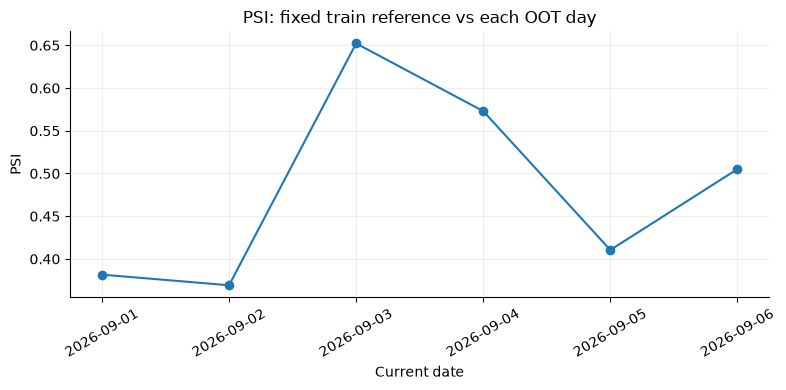

In [28]:
r_dates = train.copy()
r_dates["dt"] = "reference_period"
c_dates = oot.copy()
c_dates["dt"] = "current_period"
misaligned = Cube(["dt"], [analysis.PSI("score_a")]).compute_comparison(r_dates, c_dates)
assert misaligned.data_.value.isna().all()
display(misaligned.layout())
by_day = []
for dt, current_day in oot.groupby("dt", sort=True):
    daily = Cube(measures=[analysis.PSI("score_a")]).compute_comparison(train, current_day).data_
    by_day.append(daily.assign(dt=dt))
psi_by_day = pd.concat(by_day, ignore_index=True)
display(psi_by_day)
ax = psi_by_day.set_index("dt")["value"].plot(
    marker="o", title="PSI: fixed train reference vs each OOT day"
)
ax.set(xlabel="Current date", ylabel="PSI")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [29]:
ref_missing = pd.DataFrame({"x": [0.0, 1.0, np.nan, np.nan]})
cur_missing = pd.DataFrame({"x": [0.0, 1.0, 1.0, 0.0]})
missing_policies = Cube(
    measures=[
        analysis.PSI("x", missing="bucket", name="bucket"),
        analysis.PSI("x", missing="drop", name="drop"),
    ]
).compute_comparison(ref_missing, cur_missing)
display(missing_policies.layout())
assert missing_policies.layout().loc[0, "bucket"] > 0
assert np.isclose(missing_policies.layout().loc[0, "drop"], 0)
small = Cube(measures=[analysis.PSI("x", min_samples=10)]).compute_comparison(
    ref_missing, cur_missing
)
assert small.data_.value.isna().all()
display(small.diagnostics())
# BinDimension 的 fit 生命周期独立于 PSI 内部的参考分布分箱。
psi_with_bins = Cube([BinDimension("score_a", QuantileBinner(3))], [analysis.PSI("income")]).fit(
    train
)
display(psi_with_bins.compute_comparison(train, oot).layout())

metric,bucket,drop
0,9.21034,0.0


,reason,field,input_rows,affected_rows,dependency,message
metric,,,,,,
psi__x,reason_not_recorded,None,<NA>,<NA>,None,This calculation has not recorded a detailed c...


metric,psi__income
score_a_bin,
B1,0.26618
B2,0.14690
B3,0.24246


<a id="s18"></a>

## 18. Plan、Engine、Explain 与性能边界

Cube 负责配置和生命周期，Plan 解析依赖，PandasEngine 执行，Result 保存，Layout 展示。通常只需 Cube；直接 Engine 执行用于调试和扩展。

Count/Sum 原生聚合共享，相同条件在一次聚合内共用掩码；AUC/KS 仍逐个实际分组调用数值函数。PSI 共享维度编码，再按字段向量化计算。totals 会增加聚合粒度，批量指标不等于零额外开销。

In [30]:
plan = conditional_cube.plan(totals=True)
print("mode:", plan.mode)
print("group_columns:", plan.group_columns)
print("required_columns:", plan.required_columns())
print("unique aggregates:", len(plan.aggregates))
print("group kernels:", len(plan.group_metrics))
print("evaluation order:", [m.name for m in plan.evaluation_measures])
display(plan.explain())
direct = PandasEngine().execute(plan, df)
pd.testing.assert_frame_equal(direct.data_, conditional.data_)
print(shared_cube.explain(format="text"))
metadata = conditional.metadata_
display(
    pd.Series(
        {
            key: metadata[key]
            for key in [
                "input_rows",
                "filtered_rows",
                "analyzed_rows",
                "result_rows",
                "shared_aggregates",
                "total_grouping_sets",
            ]
        }
    )
)
# 暴露的配置为副本，重新 fit 副本不会修改 Cube 内部状态。
config_copy = shared_cube.dimensions_
config_copy[0].transformer.fit([0, 1])
assert len(shared_cube.dimensions_[0].transformer.bin_edges_) == 6

mode: single
group_columns: ('dataset',)
required_columns: ('dataset', 'channel', 'age', 'amount')
unique aggregates: 5
group kernels: 0
evaluation order: ['all_rows', 'selected_rows', 'selected_amount', 'amount_gt10', 'age_30_39']


,Section,Item,Description
0,Execution,Engine,pandas
1,Execution,Mode,single
2,Execution,Grouping,dataset
3,Dimension,dataset,Source: dataset
4,Measure,all_rows,row_count
5,Measure,selected_rows,"row_count; condition=Logical(operation='and', ..."
6,Measure,selected_amount,sum: column=amount; missing=propagate; conditi...
7,Measure,amount_gt10,sum: column=amount; missing=propagate; conditi...
8,Measure,age_30_39,"row_count; condition=Logical(operation='and', ..."
9,Execution,Shared aggregates,5


Cube Analysis Plan
  Section              Item                                                                                   Description
Execution            Engine                                                                                        pandas
Execution              Mode                                                                                        single
Execution          Grouping                                                                     score_a_bin × score_b_bin
Dimension       score_a_bin                                                                               Source: score_a
Transform       score_a_bin                                                                                  Fitted: True
Transform       score_a_bin                                                                           Fit source: score_a
Bin edges       score_a_bin (-inf, 0.30139033336246007, 0.43568669603062704, 0.5586859057652771, 0.7048163297578361, inf)
Dimen

input_rows             3600
filtered_rows          3600
analyzed_rows          3600
result_rows              15
shared_aggregates         5
total_grouping_sets       1
dtype: int64

<a id="s19"></a>

## 19. 扩展协议：从最小可运行例子理解职责

本节面向开发者，普通分析使用者可以跳过。自定义 Dimension 必须保留行顺序和索引；Measure 编译到执行节点；新 Engine 需实现后端协议。BaseTransformer 的 fit/transform/metadata 协议已通过 QuantileBinner 展示。

下面仅在 Notebook 定义教学类，不新增包功能。凡使用 _nodes、_comparison_types 的例子涉及内部协议，不承诺跨版本兼容。

In [31]:
@dataclass(frozen=True)
class AgeBand(BaseDimension):
    column: str = "age"

    @property
    def output_name(self):
        return "age_band"

    def required_columns(self):
        return (self.column,)

    def transform(self, data, context=None):
        return pd.cut(
            data[self.column], [-np.inf, 30, 50, np.inf], labels=["<=30", "31-50", ">50"]
        ).rename(self.output_name)


custom_dimension_result = Cube([AgeBand()], [Count(), EventRate("label")]).compute(df)
display(custom_dimension_result.layout())
assert custom_dimension_result.data_.query("metric == 'count'").value.sum() == len(df)


@dataclass(frozen=True)
class AdultCount(SingleSampleMeasure):
    def compile(self, context=None):
        return Count(where=Col("age") >= 18, name="adults").compile(context)


assert Cube(measures=[AdultCount()]).compute(df).layout().iloc[0, 0] == len(df)

metric,count,event_rate__label__1
age_band,,
<=30,915.0,0.51038
31-50,1399.0,0.47534
>50,1286.0,0.48600


### 19.1 一个非 PSI 的比较指标证明框架解耦
教学指标只比较每个分组两侧行数之差 current-reference。它不是分布漂移指标，也不是正式内置 API。通过已有共享 group codes 使用 bincount；不在 Measure 内重复 groupby。

In [32]:
from phl_risk.analysis._comparison_types import ComparativeCalculation, ComparisonOutput
from phl_risk.analysis._nodes import ComparativeNode, MeasureSpec


@dataclass(frozen=True)
class RowDeltaCalculation(ComparativeCalculation):
    def required_columns(self):
        return ()

    def evaluate(self, reference, current, groups, *, backend, on_invalid):
        if backend != "pandas":
            raise ValueError("Tutorial supports pandas only")
        ref = np.bincount(groups.reference_codes, minlength=groups.size)
        cur = np.bincount(groups.current_codes, minlength=groups.size)
        return ComparisonOutput((cur - ref).astype(float))


@dataclass(frozen=True)
class RowDelta(ComparativeMeasure):
    def compile(self, context=None):
        return MeasureSpec("row_delta", ComparativeNode(RowDeltaCalculation()))


extension_result = Cube(["segment"], [RowDelta()]).compute_comparison(train, oot.iloc[:600])
display(extension_result.layout())
assert extension_result.data_.value.sum() == 600 - len(train)

metric,row_delta
segment,
new,-291.0
returning,-309.0


### 19.2 AxisSpec、CubeResult、FilterExpression 与类型别名
AxisSpec 维护逻辑域与编码，CubeResult 校验唯一 canonical 坐标。通常不手工构造它们。
FilterExpression 是 required_columns + evaluate 的结构协议；Col 表达式实现它。DimensionLike/MeasureLike/EngineLike 是类型标注，不是需要实例化的功能入口。

In [33]:
axis = AxisSpec("band", "dimension", ("low", "high", None))
assert axis.codes(pd.Series(["high", None, "low"])).tolist() == [1, 2, 0]
count_spec = Count().compile()
manual_result = analysis.CubeResult(
    pd.DataFrame({"metric": ["count"], "value": [3.0]}),
    (AxisSpec("metric", "metric", ("count",)),),
    (count_spec,),
)
display(manual_result.layout())
assert isinstance(Col("age") >= 18, analysis.FilterExpression)
print("PandasEngine contract:", inspect.signature(analysis.BaseCubeEngine.execute))

metric,count
0,3.0


PandasEngine contract: (self, plan: phl_risk.analysis._plan.CubePlan, data: object, context: phl_risk.analysis._context.AnalysisContext | None = None) -> 'CubeResult'


<a id="s20"></a>

## 20. 公开 API 索引、实用配方与运行验收

本教程覆盖常用分析方法及扩展协议，不把内部实现当作稳定 API。以下索引列出当前 __all__ 的全部导出，防止遗漏。把自己的数据替换进来时，先验证列类型、标签、粒度、分母和缺失口径，再选择布局。

| 需求 | 推荐路线 |
|---|---|
| 普通分层统计 | Cube(dimensions, measures).compute(df) |
| 只看当前样本的等频表现 | BinDimension + fit_compute(df) |
| 固定参考边界应用新样本 | fit(reference).compute(current) |
| 两个分数共用数值区间 | 相同参考 + fit_field + 相同 QuantileBinner 配置 |
| 条件数量/金额 | Count(where=...) / Sum(column, where=...) |
| 非缺失计数 | Count(where=Col(field).notna()) |
| 条件占比 | Ratio(条件计数名称, 全体计数名称) |
| 逐日多样本 AUC | dimensions=['dt','dataset']，layout rows=['dt'] |
| 总计 | compute(totals=True)，total(over=...) |
| 查计算空值 | diagnostics；注意未覆盖原因与 layout 空格 |
| 固定参考逐日 PSI | 外部 groupby 日期 + compute_comparison |
| 自定义模型训练 | 不属于 analysis，参见 modeling 独立教程 |

未实现：Count 去重计数、Mean 专用类、AUC.where、PSI totals、match_by/rolling DSL、所有原因完整诊断。不要用不存在的接口替代明确的 pandas 预处理或组合指标。

In [34]:
api_sections = {
    "Cube": "3–18",
    "Count": "4–7",
    "Sum": "4–7",
    "Share": "4、6",
    "EventRate": "4、8",
    "AUC": "8、14",
    "KS": "8",
    "Ratio": "7、12",
    "Col": "5–6",
    "Predicate": "5、19",
    "BinDimension": "9–10",
    "ColumnDimension": "3",
    "QuantileBinner": "9–10",
    "Funnel": "13",
    "Stage": "13",
    "Transition": "13",
    "PSI": "16–17",
    "AnalysisContext": "8",
    "ComputePolicy": "14",
    "MissingPolicy": "14",
    "CubeResult": "11–15、19",
    "TableLayout": "11",
    "AxisSpec": "19",
    "CubePlan": "18",
    "PandasEngine": "18",
    "BaseCubeEngine": "19",
    "BaseDimension": "19",
    "BaseTransformer": "9、19",
    "BaseMeasure": "19",
    "SingleSampleMeasure": "19",
    "ComparativeMeasure": "19",
    "FilterExpression": "6、19",
    "DimensionLike": "19",
    "MeasureLike": "19",
    "EngineLike": "19",
}
assert set(analysis.__all__) == set(api_sections), "公开 API 有变化，请更新教程覆盖表"
api_index = pd.DataFrame(
    [
        {"API": name, "章节": api_sections[name], "类型": type(getattr(analysis, name)).__name__}
        for name in analysis.__all__
    ]
)
with pd.option_context("display.max_rows", 50):
    display(api_index)
print("主要方法签名（以当前安装源码为准）")
for obj in [
    Cube.compute,
    Cube.fit,
    Cube.fit_compute,
    Cube.compute_comparison,
    Cube.plan,
    Cube.explain,
    analysis.CubeResult.layout,
    analysis.CubeResult.total,
    analysis.CubeResult.diagnostics,
    QuantileBinner,
    BinDimension,
    Count,
    Sum,
    analysis.PSI,
]:
    print(obj.__qualname__, inspect.signature(obj))
print("教程运行完成：合成数据、断言、布局、诊断与扩展例子均已执行。")

,API,章节,类型
0,PSI,16–17,ABCMeta
1,SingleSampleMeasure,19,ABCMeta
2,ComparativeMeasure,19,ABCMeta
3,Col,5–6,type
4,Predicate,5、19,type
5,Funnel,13,type
6,Stage,13,type
7,Transition,13,type
8,Sum,4–7,ABCMeta
9,Ratio,7、12,ABCMeta


主要方法签名（以当前安装源码为准）
Cube.compute (self, data: object, context: phl_risk.analysis._context.AnalysisContext | None = None, *, engine: str | phl_risk.analysis.engines._base.BaseCubeEngine | None = None, totals: bool = False) -> phl_risk.analysis._result.CubeResult
Cube.fit (self, reference: object, y: object = None, context: phl_risk.analysis._context.AnalysisContext | None = None) -> 'Cube'
Cube.fit_compute (self, data: object, y: object = None, context: phl_risk.analysis._context.AnalysisContext | None = None, *, totals: bool = False) -> phl_risk.analysis._result.CubeResult
Cube.compute_comparison (self, reference: object, current: object, context: phl_risk.analysis._context.AnalysisContext | None = None, *, engine: str | phl_risk.analysis.engines._base.BaseCubeEngine | None = None) -> phl_risk.analysis._result.CubeResult
Cube.plan (self, context: phl_risk.analysis._context.AnalysisContext | None = None, *, totals: bool = False) -> phl_risk.analysis._plan.CubePlan
Cube.explain (self, cont

### 阅读后的自查

1. 你的维度表示同一粒度吗？重复用户是否应在 Cube 外去重？
2. Sum 中的缺失是未知还是零？where 的条件是否应排除缺失？
3. AUC/KS 的高分方向与 0/1 标签是否一致？Count 与有效样本量是否不同？
4. fit 学习的是哪个样本、哪个字段？current 是否复用了同一边界？
5. 总计是否按原始样本重算？是否误把比率均值当总计？
6. PSI 的两侧共同维度是否能对齐？日期不重叠时是否应外部循环？
7. diagnostics 的未记录原因和 layout 空格是否被误当成“没有问题”？

继续阅读：[条件统计](../docs/conditional_measures.md)、[诊断原因码](../docs/analysis_diagnostics.md)、[漏斗](../docs/funnel.md)、[比较分析](../docs/comparative_analysis.md)、[源码实现说明](../docs/implementation.md)。

本 Notebook 保存执行输出；环境与结果断言位于前述单元格。后续代码升级后请重新 Restart & Run All，尤其检查最终 API 覆盖断言。